# 02 - Customer, Seller, and Geolocation EDA and Preprocessing

**Member B contribution:** customers, sellers, geolocation, geographical exploratory data analysis, preprocessing, and order-level geographic feature engineering.

This notebook is the working record for Member B's analysis. It will document assumptions, validation evidence, preprocessing decisions, and the production of geography-related datasets for downstream integration.

## 2. Business Problem and Prediction Objective

The project aims to predict whether an Olist order will be delivered late. Member B contributes customer, seller, and geographic information that may explain delivery risk, such as distance proxies, state and region relationships, and the geographic distribution of sellers linked to an order.

Member A owns target engineering. This notebook will consume the agreed target only after Member A makes it available; it will not define or modify the target.

## 3. Scope and Ownership Boundaries

**In scope for Member B**

- Audit and preprocess customer, seller, and geolocation data.
- Create stable geographic attributes and Brazilian region features.
- Enrich customers and sellers with cleaned location data.
- Create order-level geographic features for the final integration step.

**Ownership boundaries**

- Raw files are read-only and must never be overwritten.
- Orders and order_items are used only as relationship bridges.
- Member A owns target engineering.
- Member C owns order-item and product preprocessing.
- Member D owns the final overall merge.
- This notebook will not modify another member's notebook, processed output, or shared source code.

## 4. Library Imports and Path Configuration

Imports and repository-relative path configuration will be added here. Paths will be resolved from the repository structure so that the notebook does not depend on a machine-specific absolute path. Randomness, display settings, and plotting conventions will be declared explicitly where relevant.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_repository_root(start: Path) -> Path:
    """Find the repository root when launched from the root or notebooks directory."""
    resolved_start = start.resolve()
    for candidate in (resolved_start, *resolved_start.parents):
        if (candidate / "data" / "raw").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate a repository containing data/raw and notebooks.")


REPO_ROOT = find_repository_root(Path.cwd())
RAW_DIR = REPO_ROOT / "data" / "raw"

display(pd.DataFrame({"resolved_path": [str(REPO_ROOT), str(RAW_DIR)]}, index=["repository_root", "raw_data_directory"]))

,resolved_path
repository_root,C:\Users\Hasini\OneDrive\Desktop\FDM project\O...
raw_data_directory,C:\Users\Hasini\OneDrive\Desktop\FDM project\O...


**Interpretation.** The repository root was resolved successfully from the active working directory, and all raw inputs are referenced through the repository-relative `data/raw` path. No machine-specific project path is embedded in the notebook.

## 5. Dataset Loading

The customer, seller, and geolocation tables will be loaded from `data/raw/` without modification. The orders and order_items tables may be read later only to connect customer and seller records to an order. Loading checks will confirm file presence, parse success, row counts, and expected columns before analysis begins.

In [2]:
CUSTOMERS_PATH = RAW_DIR / "olist_customers_dataset.csv"
SELLERS_PATH = RAW_DIR / "olist_sellers_dataset.csv"
GEOLOCATION_PATH = RAW_DIR / "olist_geolocation_dataset.csv"

required_paths = [CUSTOMERS_PATH, SELLERS_PATH, GEOLOCATION_PATH]
missing_files = [path.name for path in required_paths if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Missing required raw files: {missing_files}")

customers = pd.read_csv(
    CUSTOMERS_PATH,
    dtype={"customer_zip_code_prefix": "string"},
)
sellers = pd.read_csv(
    SELLERS_PATH,
    dtype={"seller_zip_code_prefix": "string"},
)
geolocation = pd.read_csv(
    GEOLOCATION_PATH,
    dtype={"geolocation_zip_code_prefix": "string"},
)

datasets = {
    "customers": customers,
    "sellers": sellers,
    "geolocation": geolocation,
}
zip_columns = {
    "customers": "customer_zip_code_prefix",
    "sellers": "seller_zip_code_prefix",
    "geolocation": "geolocation_zip_code_prefix",
}

load_summary = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "zip_dtype": str(frame[zip_columns[name]].dtype),
            "five_character_zip_rows": int(frame[zip_columns[name]].str.len().eq(5).sum()),
        }
        for name, frame in datasets.items()
    ]
).set_index("table")
display(load_summary)

,rows,columns,zip_dtype,five_character_zip_rows
table,,,,
customers,99441,5,string,99441
sellers,3095,4,string,3095
geolocation,1000163,5,string,1000163


**Interpretation.** The three authorized raw tables loaded successfully: customers has **99,441 rows and 5 columns**, sellers has **3,095 rows and 4 columns**, and geolocation has **1,000,163 rows and 5 columns**. Every ZIP-prefix value was loaded with pandas' string dtype and all **1,102,699** rows across the tables retain a five-character prefix, including leading zeros. Orders and order_items were not loaded.

## 6. Data Dictionary and Table Grain

This section will define each source table's business meaning, expected grain, identifiers, geographic fields, and planned use. Particular attention will be given to the distinction between `customer_id` and `customer_unique_id`, the seller identifier, geolocation ZIP-code prefixes, and one-to-many relationships introduced by order items.

In [3]:
data_dictionary = pd.DataFrame(
    [
        {
            "table": "customers",
            "expected_grain": "one row per order-specific customer_id",
            "key_fields": "customer_id; customer_unique_id",
            "geographic_fields": "customer_zip_code_prefix; customer_city; customer_state",
        },
        {
            "table": "sellers",
            "expected_grain": "one row per seller_id",
            "key_fields": "seller_id",
            "geographic_fields": "seller_zip_code_prefix; seller_city; seller_state",
        },
        {
            "table": "geolocation",
            "expected_grain": "one row per observed ZIP-prefix coordinate record",
            "key_fields": "geolocation_zip_code_prefix (non-unique)",
            "geographic_fields": "geolocation_lat; geolocation_lng; geolocation_city; geolocation_state",
        },
    ]
).set_index("table")
display(data_dictionary)

,expected_grain,key_fields,geographic_fields
table,,,
customers,one row per order-specific customer_id,customer_id; customer_unique_id,customer_zip_code_prefix; customer_city; custo...
sellers,one row per seller_id,seller_id,seller_zip_code_prefix; seller_city; seller_state
geolocation,one row per observed ZIP-prefix coordinate record,geolocation_zip_code_prefix (non-unique),geolocation_lat; geolocation_lng; geolocation_...


**Interpretation.** The tables have different grains. `customer_id` identifies an order-specific customer record, while `customer_unique_id` links repeat purchases by the same customer. Sellers are expected to be unique by `seller_id`. Geolocation is an observation table, so its ZIP prefix is expected to repeat and cannot be treated as a primary key without later aggregation.

## 7. Initial Structural Audit

The initial audit will record shapes, column names, data types, representative records, identifier coverage, and basic descriptive statistics. Schema differences from the documented Olist data model will be flagged before transformations are considered.

In [4]:
structural_summary = pd.DataFrame(
    [
        {
            "table": name,
            "shape": str(frame.shape),
            "columns": ", ".join(frame.columns),
        }
        for name, frame in datasets.items()
    ]
).set_index("table")
display(Markdown("### Shapes and columns"), structural_summary)

dtype_summary = pd.concat(
    {name: frame.dtypes.astype(str).rename("dtype") for name, frame in datasets.items()},
    names=["table", "column"],
)
display(Markdown("### Data types"), dtype_summary.to_frame())

for name, frame in datasets.items():
    display(Markdown(f"### First five rows: {name}"), frame.head(5))

### Shapes and columns

,shape,columns
table,,
customers,"(99441, 5)","customer_id, customer_unique_id, customer_zip_..."
sellers,"(3095, 4)","seller_id, seller_zip_code_prefix, seller_city..."
geolocation,"(1000163, 5)","geolocation_zip_code_prefix, geolocation_lat, ..."


### Data types

dtype
table       column                              
customers   customer_id                      str
            customer_unique_id               str
            customer_zip_code_prefix      string
            customer_city                    str
            customer_state                   str
sellers     seller_id                        str
            seller_zip_code_prefix        string
            seller_city                      str
            seller_state                     str
geolocation geolocation_zip_code_prefix   string
            geolocation_lat              float64
            geolocation_lng              float64
            geolocation_city                 str
            geolocation_state                str

### First five rows: customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,09790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,01151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,08775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### First five rows: sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,04195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### First five rows: geolocation

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,01037,-23.5456,-46.6393,sao paulo,SP
1,01046,-23.5461,-46.6448,sao paulo,SP
2,01046,-23.5461,-46.6430,sao paulo,SP
3,01041,-23.5444,-46.6395,sao paulo,SP
4,01035,-23.5416,-46.6416,sao paulo,SP


**Interpretation.** All expected columns are present. Identifier, city, and state fields loaded as strings; all three ZIP-prefix fields loaded as dedicated string columns; and geolocation latitude and longitude loaded as floating-point values. The first five records confirm the expected table layouts without requiring any mutation of the source DataFrames.

In [5]:
for name, frame in datasets.items():
    display(
        Markdown(f"### Descriptive statistics: {name}"),
        frame.describe(include="all").transpose(),
    )

### Descriptive statistics: customers

,count,unique,top,freq
customer_id,99441,99441,06b8999e2fba1a1fbc88172c00ba8bc7,1
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17
customer_zip_code_prefix,99441,14994,22790,142
customer_city,99441,4119,sao paulo,15540
customer_state,99441,27,SP,41746


### Descriptive statistics: sellers

,count,unique,top,freq
seller_id,3095,3095,3442f8959a84dea7ee197c632cb2df15,1
seller_zip_code_prefix,3095,2246,14940,49
seller_city,3095,611,sao paulo,694
seller_state,3095,23,SP,1849


### Descriptive statistics: geolocation

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
geolocation_zip_code_prefix,1000163,19015,24220,1146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_lat,"1,000,163.0000",NaN,NaN,NaN,-21.1762,5.7159,-36.6054,-23.6035,-22.9194,-19.9796,45.0659
geolocation_lng,"1,000,163.0000",NaN,NaN,NaN,-46.3905,4.2697,-101.4668,-48.5732,-46.6379,-43.7677,121.1054
geolocation_city,1000163,8011,sao paulo,135800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geolocation_state,1000163,27,SP,404268,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation.** The descriptive summaries cover every column, including categorical frequency statistics and the coordinate distribution. They confirm full non-null counts at this stage and show that high-frequency cities and states dominate each source, while the geolocation coordinates vary across a broad spatial range. These are audit observations only; no outlier rule or cleaning decision is applied here.

## 8. Missing-Value Analysis

Missingness will be measured by count and percentage for every relevant field. The analysis will distinguish true missing data from failed geographic matches and will assess whether missingness is systematic by state, city, ZIP-code prefix, or table source. No imputation strategy will be applied before its effect and modelling boundary are documented.

In [6]:
missing_summary = pd.concat(
    {
        name: pd.DataFrame(
            {
                "missing_count": frame.isna().sum(),
                "missing_percentage": frame.isna().mean().mul(100),
            }
        )
        for name, frame in datasets.items()
    },
    names=["table", "column"],
)
display(missing_summary)

missing_count  missing_percentage
table       column                                                        
customers   customer_id                              0              0.0000
            customer_unique_id                       0              0.0000
            customer_zip_code_prefix                 0              0.0000
            customer_city                            0              0.0000
            customer_state                           0              0.0000
sellers     seller_id                                0              0.0000
            seller_zip_code_prefix                   0              0.0000
            seller_city                              0              0.0000
            seller_state                             0              0.0000
geolocation geolocation_zip_code_prefix              0              0.0000
            geolocation_lat                          0              0.0000
            geolocation_lng                          0              0.0000
            geolocation_city                         0              0.0000
            geolocation_state                        0              0.0000

**Interpretation.** All audited columns contain **0 missing values (0.00%)** in customers, sellers, and geolocation. This does not guarantee that every ZIP prefix will match during later enrichment; join coverage will be assessed separately. Nothing is imputed in this audit.

## 9. Duplicate and Key-Uniqueness Analysis

This section will test expected primary-key uniqueness, exact duplicate rows, conflicting records, and multiplicity at each join key. Geolocation duplicates will be examined as repeated observations rather than removed automatically, because multiple coordinates can legitimately share a ZIP-code prefix.

In [7]:
duplicate_summary = pd.DataFrame(
    {
        "row_count": {name: len(frame) for name, frame in datasets.items()},
        "exact_duplicate_count": {name: int(frame.duplicated().sum()) for name, frame in datasets.items()},
        "exact_duplicate_percentage": {
            name: frame.duplicated().mean() * 100 for name, frame in datasets.items()
        },
    }
)
display(duplicate_summary)

,row_count,exact_duplicate_count,exact_duplicate_percentage
customers,99441,0,0.0000
sellers,3095,0,0.0000
geolocation,1000163,261831,26.1788


**Interpretation.** Customers and sellers each contain **0 exact duplicate rows**. Geolocation contains **261,831 exact duplicate rows**, equal to **26.18%** of its 1,000,163 rows. These records are only identified here; none are dropped during the audit.

In [8]:
unique_value_counts = pd.concat(
    {name: frame.nunique(dropna=False).rename("unique_values") for name, frame in datasets.items()},
    names=["table", "column"],
).to_frame()
display(Markdown("### Unique values by column"), unique_value_counts)

location_cardinality = pd.DataFrame(
    [
        {
            "table": "customers",
            "state_cardinality": customers["customer_state"].nunique(),
            "city_cardinality": customers["customer_city"].nunique(),
        },
        {
            "table": "sellers",
            "state_cardinality": sellers["seller_state"].nunique(),
            "city_cardinality": sellers["seller_city"].nunique(),
        },
        {
            "table": "geolocation",
            "state_cardinality": geolocation["geolocation_state"].nunique(),
            "city_cardinality": geolocation["geolocation_city"].nunique(),
        },
    ]
).set_index("table")
display(Markdown("### State and city cardinality"), location_cardinality)

### Unique values by column

unique_values
table       column                                    
customers   customer_id                          99441
            customer_unique_id                   96096
            customer_zip_code_prefix             14994
            customer_city                         4119
            customer_state                          27
sellers     seller_id                             3095
            seller_zip_code_prefix                2246
            seller_city                            611
            seller_state                            23
geolocation geolocation_zip_code_prefix          19015
            geolocation_lat                     717360
            geolocation_lng                     717613
            geolocation_city                      8011
            geolocation_state                       27

### State and city cardinality

,state_cardinality,city_cardinality
table,,
customers,27,4119
sellers,23,611
geolocation,27,8011


**Interpretation.** Customers span **27 states and 4,119 cities**; sellers span **23 states and 611 cities**; and geolocation spans **27 states and 8,011 city labels**. City cardinality is substantially higher than state cardinality, especially in geolocation, and will require quality review before any later encoding decision.

In [9]:
customer_unique_frequency = customers["customer_unique_id"].value_counts(dropna=False)
geolocation_zip_frequency = geolocation["geolocation_zip_code_prefix"].value_counts(dropna=False)

key_audit = pd.DataFrame(
    [
        {
            "check": "customer_id",
            "rows": len(customers),
            "unique_values": customers["customer_id"].nunique(dropna=False),
            "is_unique": customers["customer_id"].is_unique,
            "repeated_keys": int(customers["customer_id"].duplicated(keep=False).groupby(customers["customer_id"]).any().sum()),
            "rows_in_repeated_keys": int(customers["customer_id"].duplicated(keep=False).sum()),
            "maximum_repetitions": int(customers["customer_id"].value_counts(dropna=False).max()),
        },
        {
            "check": "customer_unique_id",
            "rows": len(customers),
            "unique_values": customers["customer_unique_id"].nunique(dropna=False),
            "is_unique": customers["customer_unique_id"].is_unique,
            "repeated_keys": int(customer_unique_frequency.gt(1).sum()),
            "rows_in_repeated_keys": int(customer_unique_frequency[customer_unique_frequency.gt(1)].sum()),
            "maximum_repetitions": int(customer_unique_frequency.max()),
        },
        {
            "check": "seller_id",
            "rows": len(sellers),
            "unique_values": sellers["seller_id"].nunique(dropna=False),
            "is_unique": sellers["seller_id"].is_unique,
            "repeated_keys": int(sellers["seller_id"].duplicated(keep=False).groupby(sellers["seller_id"]).any().sum()),
            "rows_in_repeated_keys": int(sellers["seller_id"].duplicated(keep=False).sum()),
            "maximum_repetitions": int(sellers["seller_id"].value_counts(dropna=False).max()),
        },
        {
            "check": "geolocation_zip_code_prefix",
            "rows": len(geolocation),
            "unique_values": geolocation["geolocation_zip_code_prefix"].nunique(dropna=False),
            "is_unique": geolocation["geolocation_zip_code_prefix"].is_unique,
            "repeated_keys": int(geolocation_zip_frequency.gt(1).sum()),
            "rows_in_repeated_keys": int(geolocation_zip_frequency[geolocation_zip_frequency.gt(1)].sum()),
            "maximum_repetitions": int(geolocation_zip_frequency.max()),
        },
    ]
).set_index("check")
display(key_audit)

,rows,unique_values,is_unique,repeated_keys,rows_in_repeated_keys,maximum_repetitions
check,,,,,,
customer_id,99441,99441,True,0,0,1
customer_unique_id,99441,96096,False,2997,6342,17
seller_id,3095,3095,True,0,0,1
geolocation_zip_code_prefix,1000163,19015,False,17972,999120,1146


**Interpretation.** All **99,441 customer_id values** and all **3,095 seller_id values** are unique. The customer table contains **96,096 customer_unique_id values**; **2,997** of them repeat, covering **6,342 rows**, and the highest repetition count is **17**. Geolocation contains **19,015 ZIP prefixes**; **17,972** repeat, covering **999,120 rows**, with a maximum of **1,146 observations** for one prefix. The geolocation ZIP prefix therefore requires aggregation before it can support a many-to-one enrichment join.

## 10. Customer Preprocessing

The raw `customers` DataFrame remains unchanged. A deep copy named `customers_clean` is created for preprocessing. ZIP prefixes are trimmed and left-padded to five digits; values that still fail the five-digit numeric pattern are represented as missing rather than guessed. City text is normalized consistently by trimming, lowercasing, Unicode-decomposing accents to ASCII, and collapsing repeated whitespace. No unsupported manual city corrections are used. State values are trimmed, uppercased, and checked against Brazil's 26 states plus the Federal District.

In [10]:
VALID_BRAZIL_STATES = frozenset(
    {"AC", "AL", "AP", "AM", "BA", "CE", "DF", "ES", "GO",
     "MA", "MT", "MS", "MG", "PA", "PB", "PR", "PE", "PI",
     "RJ", "RN", "RS", "RO", "RR", "SC", "SP", "SE", "TO"}
)


def standardize_zip_prefix(series: pd.Series) -> pd.Series:
    standardized = series.astype("string").str.strip().str.zfill(5)
    return standardized.where(standardized.str.fullmatch(r"\d{5}", na=False))


def normalize_city_text(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.replace(r"\s+", " ", regex=True)
    )


def normalize_state_text(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().str.upper()


raw_signatures = {
    name: int(pd.util.hash_pandas_object(frame, index=True).sum())
    for name, frame in datasets.items()
}

customers_clean = customers.copy(deep=True).assign(
    customer_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["customer_zip_code_prefix"]),
    customer_city=lambda frame: normalize_city_text(frame["customer_city"]),
    customer_state=lambda frame: normalize_state_text(frame["customer_state"]),
)

customer_cleaning_audit = pd.Series(
    {
        "rows_before": len(customers),
        "rows_after": len(customers_clean),
        "zip_values_changed": int(customers_clean["customer_zip_code_prefix"].ne(customers["customer_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(customers_clean["customer_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(customers_clean["customer_city"].ne(customers["customer_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(customers_clean["customer_state"].ne(customers["customer_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~customers_clean["customer_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="customers",
).to_frame("count")
display(customer_cleaning_audit)

,count
rows_before,99441
rows_after,99441
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,0
state_values_changed,0
invalid_state_rows,0


**Interpretation.** Customer row count is preserved at **99,441**. All ZIP prefixes were already valid five-character strings, all city and state values already matched the normalization rules, and **0 customer state rows** fall outside the 27 valid federal-unit abbreviations. The cleaned copy is retained separately from the raw DataFrame.

## 11. Seller Preprocessing

The same deterministic text rules are applied to a deep copy named `sellers_clean`. Reusing the ZIP, city, and state functions keeps customer and seller features comparable and avoids table-specific manual corrections.

In [11]:
sellers_clean = sellers.copy(deep=True).assign(
    seller_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["seller_zip_code_prefix"]),
    seller_city=lambda frame: normalize_city_text(frame["seller_city"]),
    seller_state=lambda frame: normalize_state_text(frame["seller_state"]),
)

seller_cleaning_audit = pd.Series(
    {
        "rows_before": len(sellers),
        "rows_after": len(sellers_clean),
        "zip_values_changed": int(sellers_clean["seller_zip_code_prefix"].ne(sellers["seller_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(sellers_clean["seller_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(sellers_clean["seller_city"].ne(sellers["seller_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(sellers_clean["seller_state"].ne(sellers["seller_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~sellers_clean["seller_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="sellers",
).to_frame("count")
display(seller_cleaning_audit)

,count
rows_before,3095
rows_after,3095
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,6
state_values_changed,0
invalid_state_rows,0


**Interpretation.** Seller row count is preserved at **3,095**. ZIP and state values required no changes, while **6 city values** changed under the uniform normalization rule. There are **0 invalid seller states** and no manual city substitutions.

## 12. Geolocation EDA and Validation

A deep copy named `geolocation_clean` receives the same ZIP, city, and state normalization. Coordinate plausibility is evaluated separately from statistical outliers. The broad bounds used here are latitude **-34 to 6** and longitude **-74 to -34**, rounded outward from the mainland extreme points published by [IBGE's 2022 territorial table](https://anuario.ibge.gov.br/images/aeb/2023/s1/2_pdf/s1t1101.pdf). IQR diagnostics are reported for context only: IQR outliers are not removed because statistical extremeness does not establish geographic invalidity.

In [12]:
geolocation_clean = geolocation.copy(deep=True).assign(
    geolocation_zip_code_prefix=lambda frame: standardize_zip_prefix(frame["geolocation_zip_code_prefix"]),
    geolocation_city=lambda frame: normalize_city_text(frame["geolocation_city"]),
    geolocation_state=lambda frame: normalize_state_text(frame["geolocation_state"]),
)

geolocation_cleaning_audit = pd.Series(
    {
        "rows_before": len(geolocation),
        "rows_after": len(geolocation_clean),
        "zip_values_changed": int(geolocation_clean["geolocation_zip_code_prefix"].ne(geolocation["geolocation_zip_code_prefix"]).fillna(False).sum()),
        "invalid_or_missing_zip_rows": int(geolocation_clean["geolocation_zip_code_prefix"].isna().sum()),
        "city_values_changed": int(geolocation_clean["geolocation_city"].ne(geolocation["geolocation_city"].astype("string")).fillna(False).sum()),
        "state_values_changed": int(geolocation_clean["geolocation_state"].ne(geolocation["geolocation_state"].astype("string")).fillna(False).sum()),
        "invalid_state_rows": int((~geolocation_clean["geolocation_state"].isin(VALID_BRAZIL_STATES)).sum()),
    },
    name="geolocation",
).to_frame("count")
display(geolocation_cleaning_audit)

,count
rows_before,1000163
rows_after,1000163
zip_values_changed,0
invalid_or_missing_zip_rows,0
city_values_changed,73453
state_values_changed,0
invalid_state_rows,0


**Interpretation.** All **1,000,163 geolocation rows** are retained. ZIP and state values required no changes, **73,453 city values** changed under the uniform text rule, and normalized city cardinality falls from 8,011 to 5,966 labels. All state values belong to the valid 27-unit set.

In [13]:
LATITUDE_MIN, LATITUDE_MAX = -34.0, 6.0
LONGITUDE_MIN, LONGITUDE_MAX = -74.0, -34.0

latitude_below_bound = geolocation_clean["geolocation_lat"].lt(LATITUDE_MIN)
latitude_above_bound = geolocation_clean["geolocation_lat"].gt(LATITUDE_MAX)
longitude_below_bound = geolocation_clean["geolocation_lng"].lt(LONGITUDE_MIN)
longitude_above_bound = geolocation_clean["geolocation_lng"].gt(LONGITUDE_MAX)
coordinate_outside_bounds = (
    latitude_below_bound
    | latitude_above_bound
    | longitude_below_bound
    | longitude_above_bound
)
coordinate_within_bounds = (
    geolocation_clean["geolocation_lat"].notna()
    & geolocation_clean["geolocation_lng"].notna()
    & ~coordinate_outside_bounds
)

coordinate_bounds_audit = pd.Series(
    {
        "latitude_min_observed": geolocation_clean["geolocation_lat"].min(),
        "latitude_max_observed": geolocation_clean["geolocation_lat"].max(),
        "longitude_min_observed": geolocation_clean["geolocation_lng"].min(),
        "longitude_max_observed": geolocation_clean["geolocation_lng"].max(),
        "latitude_below_bound_rows": int(latitude_below_bound.sum()),
        "latitude_above_bound_rows": int(latitude_above_bound.sum()),
        "longitude_below_bound_rows": int(longitude_below_bound.sum()),
        "longitude_above_bound_rows": int(longitude_above_bound.sum()),
        "any_coordinate_outside_bounds_rows": int(coordinate_outside_bounds.sum()),
        "zip_prefixes_with_out_of_bounds_coordinates": int(geolocation_clean.loc[coordinate_outside_bounds, "geolocation_zip_code_prefix"].nunique()),
    },
    name="coordinate_bounds",
).to_frame("value")
display(coordinate_bounds_audit)

iqr_diagnostics = []
for column in ["geolocation_lat", "geolocation_lng"]:
    q1, q3 = geolocation_clean[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_diagnostics.append(
        {
            "coordinate": column,
            "q1": q1,
            "q3": q3,
            "lower_iqr_fence": lower_fence,
            "upper_iqr_fence": upper_fence,
            "iqr_outlier_rows_not_removed": int((~geolocation_clean[column].between(lower_fence, upper_fence)).sum()),
        }
    )
display(pd.DataFrame(iqr_diagnostics).set_index("coordinate"))

,value
latitude_min_observed,-36.6054
latitude_max_observed,45.0659
longitude_min_observed,-101.4668
longitude_max_observed,121.1054
latitude_below_bound_rows,5.0000
latitude_above_bound_rows,26.0000
longitude_below_bound_rows,4.0000
longitude_above_bound_rows,33.0000
any_coordinate_outside_bounds_rows,42.0000
zip_prefixes_with_out_of_bounds_coordinates,21.0000


,q1,q3,lower_iqr_fence,upper_iqr_fence,iqr_outlier_rows_not_removed
coordinate,,,,,
geolocation_lat,-23.6035,-19.9796,-29.0394,-14.5437,168240
geolocation_lng,-48.5732,-43.7677,-55.7814,-36.5595,42348


**Interpretation.** The raw ranges include latitude from **-36.6054 to 45.0659** and longitude from **-101.4668 to 121.1054**. Exactly **42 rows across 21 ZIP prefixes** have at least one coordinate outside the selected Brazilian bounds: 5 are below the latitude minimum, 26 exceed the latitude maximum, 4 are west of the longitude minimum, and 33 exceed the longitude maximum. Conditions overlap, so component counts do not sum to 42. The IQR rules identify 168,240 latitude values and 42,348 longitude values as statistical outliers, but none are removed for that reason.

In [14]:
zip_column = "geolocation_zip_code_prefix"
zip_record_counts = geolocation_clean.groupby(zip_column, dropna=False).size()
zip_coordinate_pair_counts = (
    geolocation_clean
    .drop_duplicates([zip_column, "geolocation_lat", "geolocation_lng"])
    .groupby(zip_column, dropna=False)
    .size()
)
zip_city_counts = geolocation_clean.groupby(zip_column, dropna=False)["geolocation_city"].nunique(dropna=True)
zip_state_counts = geolocation_clean.groupby(zip_column, dropna=False)["geolocation_state"].nunique(dropna=True)

zip_profile = pd.concat(
    [
        zip_record_counts.rename("raw_record_count"),
        zip_coordinate_pair_counts.rename("unique_coordinate_pair_count"),
        zip_city_counts.rename("normalized_city_count"),
        zip_state_counts.rename("state_count"),
    ],
    axis=1,
)

zip_conflict_summary = pd.Series(
    {
        "total_zip_prefixes": len(zip_profile),
        "prefixes_with_multiple_records": int(zip_profile["raw_record_count"].gt(1).sum()),
        "prefixes_with_multiple_coordinate_pairs": int(zip_profile["unique_coordinate_pair_count"].gt(1).sum()),
        "prefixes_with_multiple_normalized_cities": int(zip_profile["normalized_city_count"].gt(1).sum()),
        "prefixes_with_multiple_states": int(zip_profile["state_count"].gt(1).sum()),
        "maximum_records_for_one_prefix": int(zip_profile["raw_record_count"].max()),
        "maximum_cities_for_one_prefix": int(zip_profile["normalized_city_count"].max()),
        "maximum_states_for_one_prefix": int(zip_profile["state_count"].max()),
    },
    name="zip_prefix_audit",
).to_frame("count")
display(zip_conflict_summary)

,count
total_zip_prefixes,19015
prefixes_with_multiple_records,17972
prefixes_with_multiple_coordinate_pairs,17781
prefixes_with_multiple_normalized_cities,548
prefixes_with_multiple_states,8
maximum_records_for_one_prefix,1146
maximum_cities_for_one_prefix,4
maximum_states_for_one_prefix,2


**Interpretation.** Of **19,015 ZIP prefixes**, **17,972** have multiple raw records, **17,781** have multiple coordinate pairs, **548** have multiple normalized city labels, and **8** have multiple state labels. One prefix has as many as 1,146 records. A deterministic ZIP-level aggregation is therefore required before customer or seller enrichment.

## 13. Data-Quality Observations

The audit supports four preprocessing decisions. First, text normalization can be deterministic because all state abbreviations are valid and no city requires an unsupported manual correction. Second, the 42 rows outside the broad Brazilian bounds should not influence coordinates, but their source records should remain represented in ZIP-level record counts. Third, IQR status alone is not a deletion criterion. Fourth, extensive ZIP repetition and smaller city/state conflicts require a documented aggregation rule before joining.

## 14. Geolocation Preprocessing

Rows are not deleted from `geolocation_clean`. For the 42 records outside the documented broad bounds, both coordinates are masked as missing in the cleaned copy so an implausible pair cannot partially influence a centroid. Missing coordinates are never replaced with zero.

The ZIP-level table `geolocation_zip_clean` uses median latitude and longitude over valid coordinate records. A median is robust to extreme or noisy observations and represents the center of all available records; selecting an arbitrary first row would make the result dependent on file order. Normalized city and state use the most frequent value, with an alphabetical tie-break for reproducibility. The raw record count, valid-coordinate count, out-of-bounds count, and label-conflict counts remain available for quality assessment.

In [15]:
def deterministic_mode(series: pd.Series):
    counts = series.dropna().value_counts()
    if counts.empty:
        return pd.NA
    tied_modes = counts[counts.eq(counts.max())].index.astype(str)
    return sorted(tied_modes)[0]


geolocation_clean = geolocation_clean.assign(
    coordinate_within_brazil_bounds=coordinate_within_bounds,
    coordinate_outside_brazil_bounds=coordinate_outside_bounds,
    geolocation_lat=lambda frame: frame["geolocation_lat"].where(frame["coordinate_within_brazil_bounds"]),
    geolocation_lng=lambda frame: frame["geolocation_lng"].where(frame["coordinate_within_brazil_bounds"]),
)

geolocation_zip_clean = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False, dropna=False)
    .agg(
        geolocation_lat=("geolocation_lat", "median"),
        geolocation_lng=("geolocation_lng", "median"),
        geolocation_city=("geolocation_city", deterministic_mode),
        geolocation_state=("geolocation_state", deterministic_mode),
        geolocation_record_count=("geolocation_zip_code_prefix", "size"),
        geolocation_valid_coordinate_count=("coordinate_within_brazil_bounds", "sum"),
        geolocation_out_of_bounds_count=("coordinate_outside_brazil_bounds", "sum"),
        geolocation_city_count=("geolocation_city", "nunique"),
        geolocation_state_count=("geolocation_state", "nunique"),
    )
)

geolocation_zip_validation = pd.Series(
    {
        "zip_centroid_rows": len(geolocation_zip_clean),
        "unique_zip_prefixes": geolocation_zip_clean["geolocation_zip_code_prefix"].nunique(dropna=False),
        "zip_prefix_is_unique": geolocation_zip_clean["geolocation_zip_code_prefix"].is_unique,
        "raw_records_accounted_for": int(geolocation_zip_clean["geolocation_record_count"].sum()),
        "valid_coordinate_records": int(geolocation_zip_clean["geolocation_valid_coordinate_count"].sum()),
        "out_of_bounds_records_masked": int(geolocation_zip_clean["geolocation_out_of_bounds_count"].sum()),
        "centroids_missing_latitude_or_longitude": int(geolocation_zip_clean[["geolocation_lat", "geolocation_lng"]].isna().any(axis=1).sum()),
        "masked_coordinates_replaced_with_zero": int(geolocation_clean.loc[coordinate_outside_bounds, ["geolocation_lat", "geolocation_lng"]].eq(0).any(axis=1).sum()),
    },
    name="geolocation_zip_clean",
).to_frame("value")

assert geolocation_zip_clean["geolocation_zip_code_prefix"].is_unique
assert geolocation_zip_clean["geolocation_record_count"].sum() == len(geolocation)
assert geolocation_clean.loc[coordinate_outside_bounds, ["geolocation_lat", "geolocation_lng"]].isna().all().all()
display(geolocation_zip_validation)
display(geolocation_zip_clean.head())

,value
zip_centroid_rows,19015
unique_zip_prefixes,19015
zip_prefix_is_unique,True
raw_records_accounted_for,1000163
valid_coordinate_records,1000121
out_of_bounds_records_masked,42
centroids_missing_latitude_or_longitude,5
masked_coordinates_replaced_with_zero,0


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_record_count,geolocation_valid_coordinate_count,geolocation_out_of_bounds_count,geolocation_city_count,geolocation_state_count
0,01001,-23.5504,-46.6340,sao paulo,SP,26,26,0,1,1
1,01002,-23.5486,-46.6351,sao paulo,SP,13,13,0,1,1
2,01003,-23.5490,-46.6353,sao paulo,SP,17,17,0,1,1
3,01004,-23.5495,-46.6348,sao paulo,SP,22,22,0,1,1
4,01005,-23.5496,-46.6365,sao paulo,SP,25,25,0,1,1


**Interpretation.** The result has one unique row for each of the **19,015 ZIP prefixes**, and its record-count column accounts for all **1,000,163 raw geolocation rows**. Exactly **42 out-of-bounds coordinate pairs** are masked rather than deleted or set to zero, leaving **1,000,121 valid coordinate records**. Five ZIP prefixes have no valid coordinate left, so their centroid coordinates correctly remain missing.

## 15. Customer and Seller Location Enrichment

Customers and sellers are enriched independently from the unique ZIP centroid table using left joins with pandas' `many_to_one` validation. Source and geolocation fields receive explicit prefixes to preserve meaning. A missing-geolocation indicator is true when either joined coordinate is unavailable. Missing coordinates remain missing and are never replaced by zero. Assertions require row counts and entity-key uniqueness to remain unchanged.

In [16]:
customer_geo_lookup = geolocation_zip_clean.rename(
    columns={
        "geolocation_zip_code_prefix": "customer_zip_code_prefix",
        "geolocation_lat": "customer_latitude",
        "geolocation_lng": "customer_longitude",
        "geolocation_city": "customer_geolocation_city",
        "geolocation_state": "customer_geolocation_state",
        "geolocation_record_count": "customer_geolocation_record_count",
        "geolocation_valid_coordinate_count": "customer_geolocation_valid_coordinate_count",
        "geolocation_out_of_bounds_count": "customer_geolocation_out_of_bounds_count",
        "geolocation_city_count": "customer_geolocation_city_count",
        "geolocation_state_count": "customer_geolocation_state_count",
    }
)
seller_geo_lookup = geolocation_zip_clean.rename(
    columns={
        "geolocation_zip_code_prefix": "seller_zip_code_prefix",
        "geolocation_lat": "seller_latitude",
        "geolocation_lng": "seller_longitude",
        "geolocation_city": "seller_geolocation_city",
        "geolocation_state": "seller_geolocation_state",
        "geolocation_record_count": "seller_geolocation_record_count",
        "geolocation_valid_coordinate_count": "seller_geolocation_valid_coordinate_count",
        "geolocation_out_of_bounds_count": "seller_geolocation_out_of_bounds_count",
        "geolocation_city_count": "seller_geolocation_city_count",
        "geolocation_state_count": "seller_geolocation_state_count",
    }
)

customers_geo_clean = (
    customers_clean
    .merge(customer_geo_lookup, on="customer_zip_code_prefix", how="left", validate="many_to_one")
    .assign(
        customer_geolocation_missing=lambda frame: frame[["customer_latitude", "customer_longitude"]].isna().any(axis=1)
    )
)
sellers_geo_clean = (
    sellers_clean
    .merge(seller_geo_lookup, on="seller_zip_code_prefix", how="left", validate="many_to_one")
    .assign(
        seller_geolocation_missing=lambda frame: frame[["seller_latitude", "seller_longitude"]].isna().any(axis=1)
    )
)

join_validation = pd.DataFrame(
    [
        {
            "table": "customers_geo_clean",
            "rows_before": len(customers_clean),
            "rows_after": len(customers_geo_clean),
            "row_increase": len(customers_geo_clean) - len(customers_clean),
            "entity_key_remains_unique": customers_geo_clean["customer_id"].is_unique,
            "missing_geolocation_rows": int(customers_geo_clean["customer_geolocation_missing"].sum()),
            "missing_coordinates_equal_zero": int(customers_geo_clean.loc[customers_geo_clean["customer_geolocation_missing"], ["customer_latitude", "customer_longitude"]].eq(0).any(axis=1).sum()),
        },
        {
            "table": "sellers_geo_clean",
            "rows_before": len(sellers_clean),
            "rows_after": len(sellers_geo_clean),
            "row_increase": len(sellers_geo_clean) - len(sellers_clean),
            "entity_key_remains_unique": sellers_geo_clean["seller_id"].is_unique,
            "missing_geolocation_rows": int(sellers_geo_clean["seller_geolocation_missing"].sum()),
            "missing_coordinates_equal_zero": int(sellers_geo_clean.loc[sellers_geo_clean["seller_geolocation_missing"], ["seller_latitude", "seller_longitude"]].eq(0).any(axis=1).sum()),
        },
    ]
).set_index("table")

assert len(customers_geo_clean) == len(customers_clean)
assert len(sellers_geo_clean) == len(sellers_clean)
assert customers_geo_clean["customer_id"].is_unique
assert sellers_geo_clean["seller_id"].is_unique
display(join_validation)

,rows_before,rows_after,row_increase,entity_key_remains_unique,missing_geolocation_rows,missing_coordinates_equal_zero
table,,,,,,
customers_geo_clean,99441,99441,0,True,279,0
sellers_geo_clean,3095,3095,0,True,7,0


**Interpretation.** Both joins pass explicit many-to-one validation. Customer rows remain **99,441** and seller rows remain **3,095**, with unique entity identifiers and no row increase. The missing-geolocation indicators identify **279 customer rows** and **7 seller rows** with unmatched or unavailable coordinates; none of these missing values is replaced by zero.

## 16. Brazilian Region Feature Engineering

A single explicit mapping assigns all 27 validated federal-unit abbreviations to North, Northeast, Central-West, Southeast, or South. Mapping is based on each entity's own state field, not on a potentially conflicting geolocation label. Unknown states would remain missing rather than being silently assigned.

In [17]:
STATE_TO_REGION = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North",
    "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast",
    "MA": "Northeast", "PB": "Northeast", "PE": "Northeast",
    "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Central-West", "GO": "Central-West",
    "MT": "Central-West", "MS": "Central-West",
    "ES": "Southeast", "MG": "Southeast",
    "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}
EXPECTED_REGIONS = {"North", "Northeast", "Central-West", "Southeast", "South"}

assert set(STATE_TO_REGION) == VALID_BRAZIL_STATES
assert set(STATE_TO_REGION.values()) == EXPECTED_REGIONS

customers_clean = customers_clean.assign(
    customer_region=customers_clean["customer_state"].map(STATE_TO_REGION).astype("string")
)
sellers_clean = sellers_clean.assign(
    seller_region=sellers_clean["seller_state"].map(STATE_TO_REGION).astype("string")
)
geolocation_clean = geolocation_clean.assign(
    geolocation_region=geolocation_clean["geolocation_state"].map(STATE_TO_REGION).astype("string")
)
geolocation_zip_clean = geolocation_zip_clean.assign(
    geolocation_region=geolocation_zip_clean["geolocation_state"].map(STATE_TO_REGION).astype("string")
)
customers_geo_clean = customers_geo_clean.assign(
    customer_region=customers_geo_clean["customer_state"].map(STATE_TO_REGION).astype("string")
)
sellers_geo_clean = sellers_geo_clean.assign(
    seller_region=sellers_geo_clean["seller_state"].map(STATE_TO_REGION).astype("string")
)

raw_dataframes_unchanged = {
    name: int(pd.util.hash_pandas_object(frame, index=True).sum()) == raw_signatures[name]
    for name, frame in datasets.items()
}
region_validation = pd.Series(
    {
        "mapped_federal_units": len(STATE_TO_REGION),
        "mapped_regions": len(set(STATE_TO_REGION.values())),
        "customers_missing_region": int(customers_clean["customer_region"].isna().sum()),
        "sellers_missing_region": int(sellers_clean["seller_region"].isna().sum()),
        "geolocation_zip_rows_missing_region": int(geolocation_zip_clean["geolocation_region"].isna().sum()),
        "raw_customers_unchanged": raw_dataframes_unchanged["customers"],
        "raw_sellers_unchanged": raw_dataframes_unchanged["sellers"],
        "raw_geolocation_unchanged": raw_dataframes_unchanged["geolocation"],
    },
    name="region_and_raw_validation",
).to_frame("value")
display(region_validation)
display(
    customers_clean["customer_region"].value_counts().rename("customer_rows").to_frame(),
    sellers_clean["seller_region"].value_counts().rename("seller_rows").to_frame(),
)

,value
mapped_federal_units,27
mapped_regions,5
customers_missing_region,0
sellers_missing_region,0
geolocation_zip_rows_missing_region,0
raw_customers_unchanged,True
raw_sellers_unchanged,True
raw_geolocation_unchanged,True


,customer_rows
customer_region,
Southeast,68266
South,14148
Northeast,9394
Central-West,5782
North,1851


,seller_rows
seller_region,
Southeast,2287
South,668
Central-West,79
Northeast,56
North,5


**Interpretation.** The mapping covers exactly **27 federal units and 5 regions**, with **0 missing customer regions**, **0 missing seller regions**, and **0 missing ZIP-level geolocation regions**. Content-signature checks return true for customers, sellers, and geolocation, confirming that all three raw DataFrames remain unchanged.

## 16.1 Geographic EDA Visualisations

These figures describe customer, seller, and geolocation coverage only. The target has not been joined, so the charts do not support conclusions about delivery lateness. Each figure is saved under `report/figures/member_b/`.

In [18]:
import os
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "olist_member_b_matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

FIGURE_DIR = REPO_ROOT / "report" / "figures" / "member_b"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_FIGURES = {}

sns.set_theme(style="whitegrid", context="notebook")
PRIMARY_COLOR = "#287271"
SECONDARY_COLOR = "#D1495B"
EDGE_COLOR = "#222222"


def save_figure(fig, filename: str) -> Path:
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight", facecolor="white")
    GENERATED_FIGURES[filename] = output_path
    plt.show()
    plt.close(fig)
    return output_path


def label_horizontal_bars(ax, bars, formatter=lambda value: f"{int(value):,}"):
    ax.bar_label(bars, labels=[formatter(bar.get_width()) for bar in bars], padding=4, fontsize=9)
    ax.margins(x=0.12)


print(f"Figures will be saved to: {FIGURE_DIR}")

Figures will be saved to: C:\Users\Hasini\OneDrive\Desktop\FDM project\Olist-late-delivery-prediction\report\figures\member_b


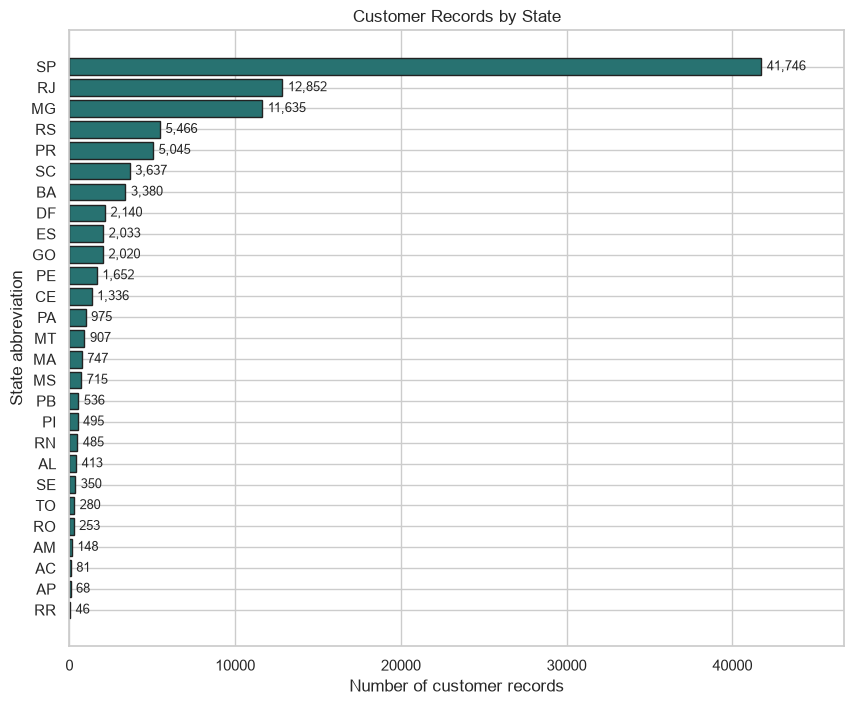

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/customer_counts_by_state.png')

In [19]:
customer_state_counts = customers_clean["customer_state"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(customer_state_counts.index, customer_state_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Customer Records by State")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("State abbreviation")
save_figure(fig, "customer_counts_by_state.png")

**Observation.** Customer records are geographically concentrated: SP has **41,746**, followed by RJ with 12,852 and MG with 11,635. This describes representation in the customer table only and does not indicate late-delivery risk.

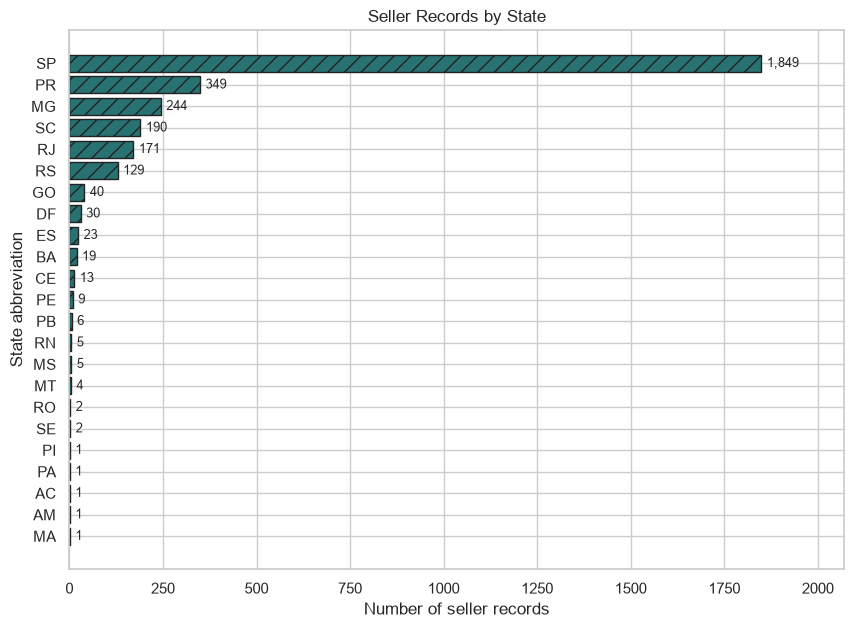

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/seller_counts_by_state.png')

In [20]:
seller_state_counts = sellers_clean["seller_state"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(seller_state_counts.index, seller_state_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Seller Records by State")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("State abbreviation")
save_figure(fig, "seller_counts_by_state.png")

**Observation.** Sellers are more concentrated in SP, which contains **1,849 of 3,095 sellers**. PR is second with 349 and MG third with 244; four valid Brazilian states have no seller record in this table.

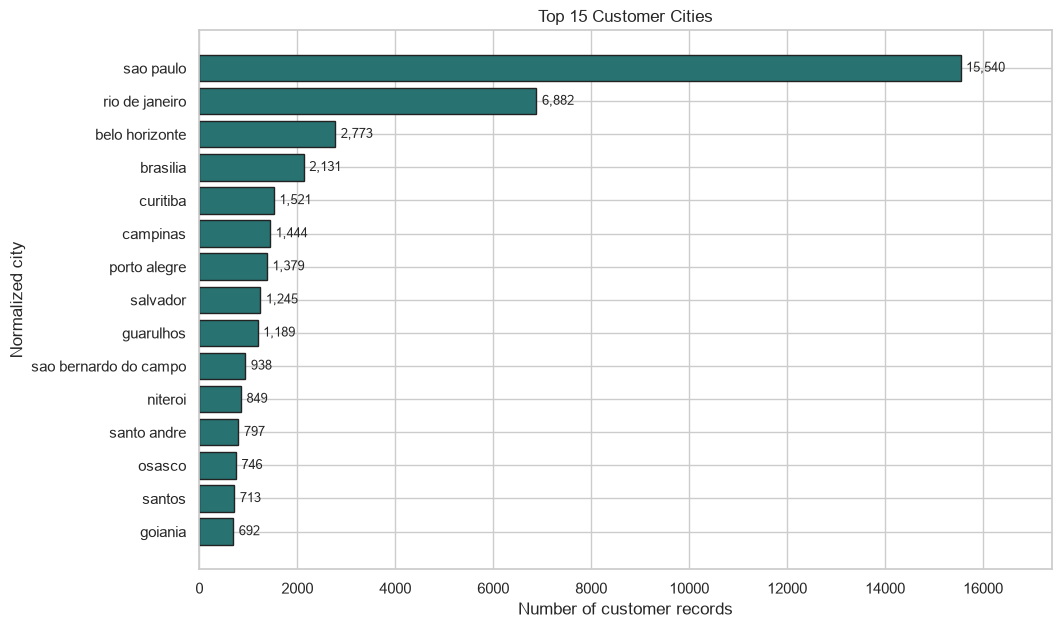

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/top_15_customer_cities.png')

In [21]:
top_customer_cities = customers_clean["customer_city"].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_customer_cities.index, top_customer_cities.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Top 15 Customer Cities")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("Normalized city")
save_figure(fig, "top_15_customer_cities.png")

**Observation.** Sao Paulo leads with **15,540 customer records**, more than twice Rio de Janeiro's 6,882. The chart is intentionally limited to 15 cities so labels remain readable; the customer table contains 4,119 distinct normalized cities.

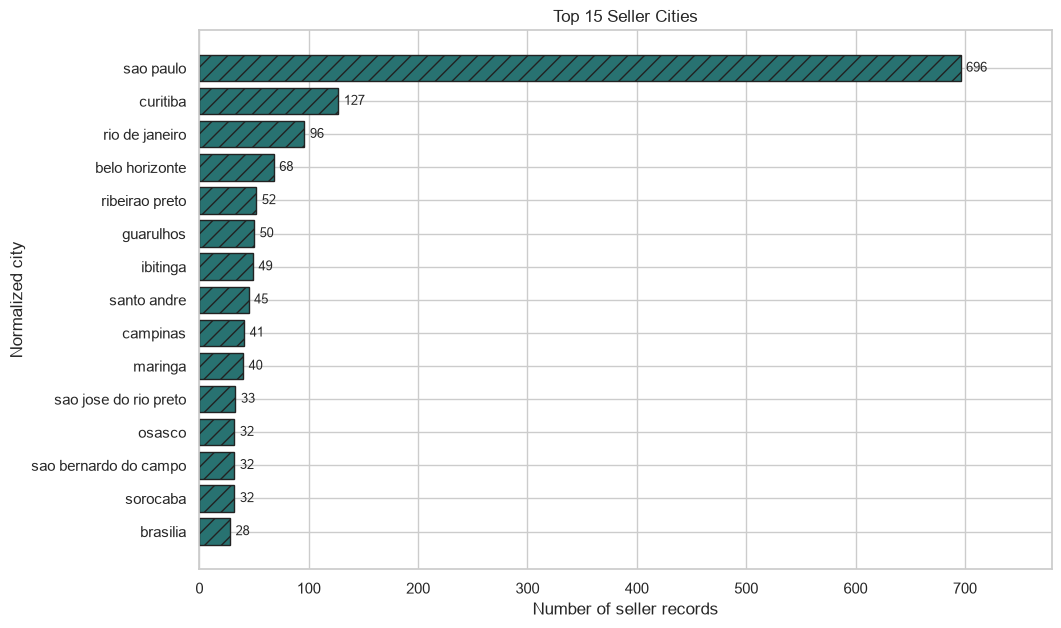

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/top_15_seller_cities.png')

In [22]:
top_seller_cities = sellers_clean["seller_city"].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_seller_cities.index, top_seller_cities.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Top 15 Seller Cities")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("Normalized city")
save_figure(fig, "top_15_seller_cities.png")

**Observation.** Sao Paulo contains **694 seller records**, well above Curitiba with 127 and Rio de Janeiro with 96. Only the top 15 of 606 normalized seller cities are displayed.

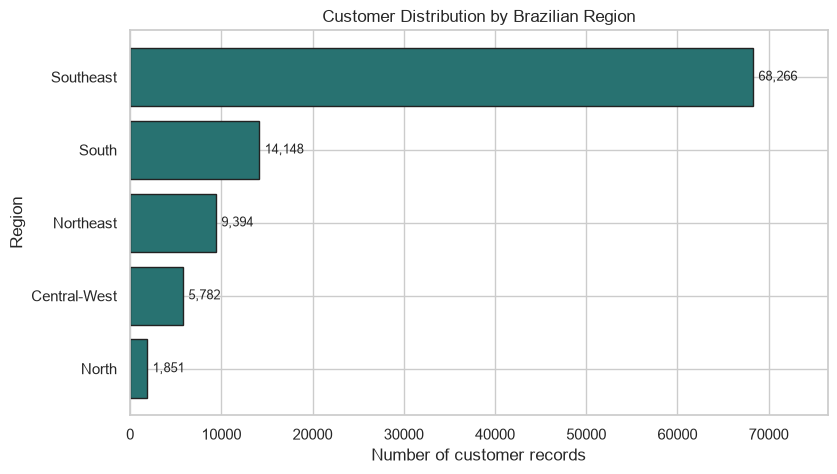

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/customer_distribution_by_region.png')

In [23]:
customer_region_counts = customers_clean["customer_region"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(customer_region_counts.index, customer_region_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR)
label_horizontal_bars(ax, bars)
ax.set_title("Customer Distribution by Brazilian Region")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("Region")
save_figure(fig, "customer_distribution_by_region.png")

**Observation.** The Southeast accounts for **68,266 customer records**, followed by the South with 14,148. The North has the smallest representation with 1,851 records.

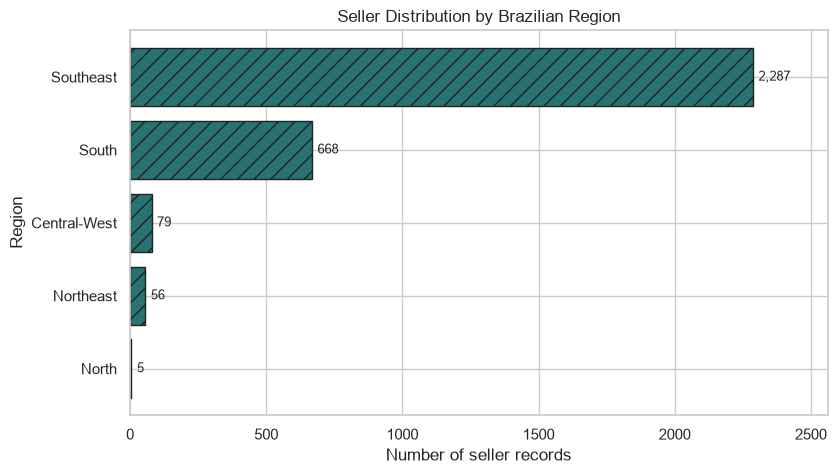

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/seller_distribution_by_region.png')

In [24]:
seller_region_counts = sellers_clean["seller_region"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(seller_region_counts.index, seller_region_counts.values, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
label_horizontal_bars(ax, bars)
ax.set_title("Seller Distribution by Brazilian Region")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("Region")
save_figure(fig, "seller_distribution_by_region.png")

**Observation.** The Southeast contains **2,287 sellers**, while the South contains 668. Only 5 sellers are located in the North, showing substantial regional imbalance in seller representation.

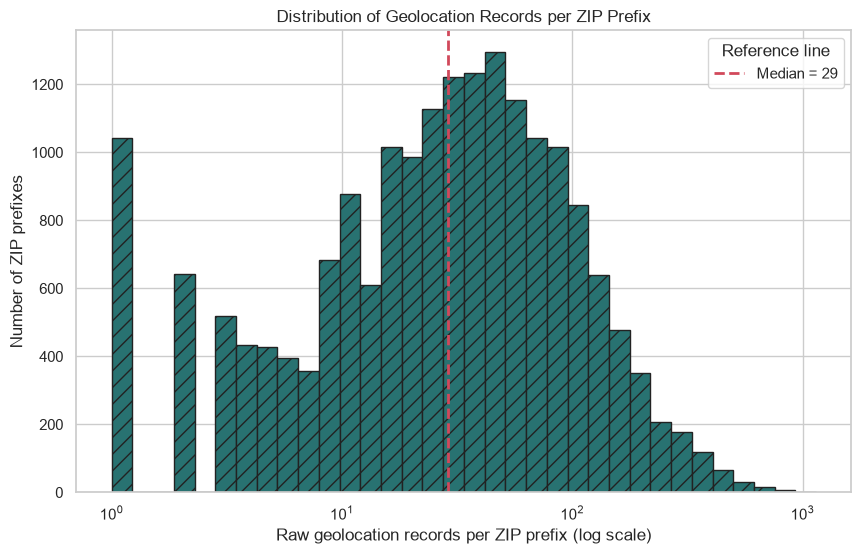

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/geolocation_records_per_zip_prefix.png')

In [25]:
zip_record_distribution = geolocation_zip_clean["geolocation_record_count"]
log_bins = np.logspace(0, np.log10(zip_record_distribution.max()), 35)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(zip_record_distribution, bins=log_bins, color=PRIMARY_COLOR, edgecolor=EDGE_COLOR, hatch="//")
median_records = zip_record_distribution.median()
ax.axvline(median_records, color=SECONDARY_COLOR, linestyle="--", linewidth=2, label=f"Median = {median_records:,.0f}")
ax.set_xscale("log")
ax.set_title("Distribution of Geolocation Records per ZIP Prefix")
ax.set_xlabel("Raw geolocation records per ZIP prefix (log scale)")
ax.set_ylabel("Number of ZIP prefixes")
ax.legend(title="Reference line")
save_figure(fig, "geolocation_records_per_zip_prefix.png")

**Observation.** The distribution is strongly right-skewed: the median ZIP prefix has **29 records**, 95% have no more than 180, and the maximum is 1,146. The logarithmic x-axis keeps both sparse and highly repeated prefixes visible.

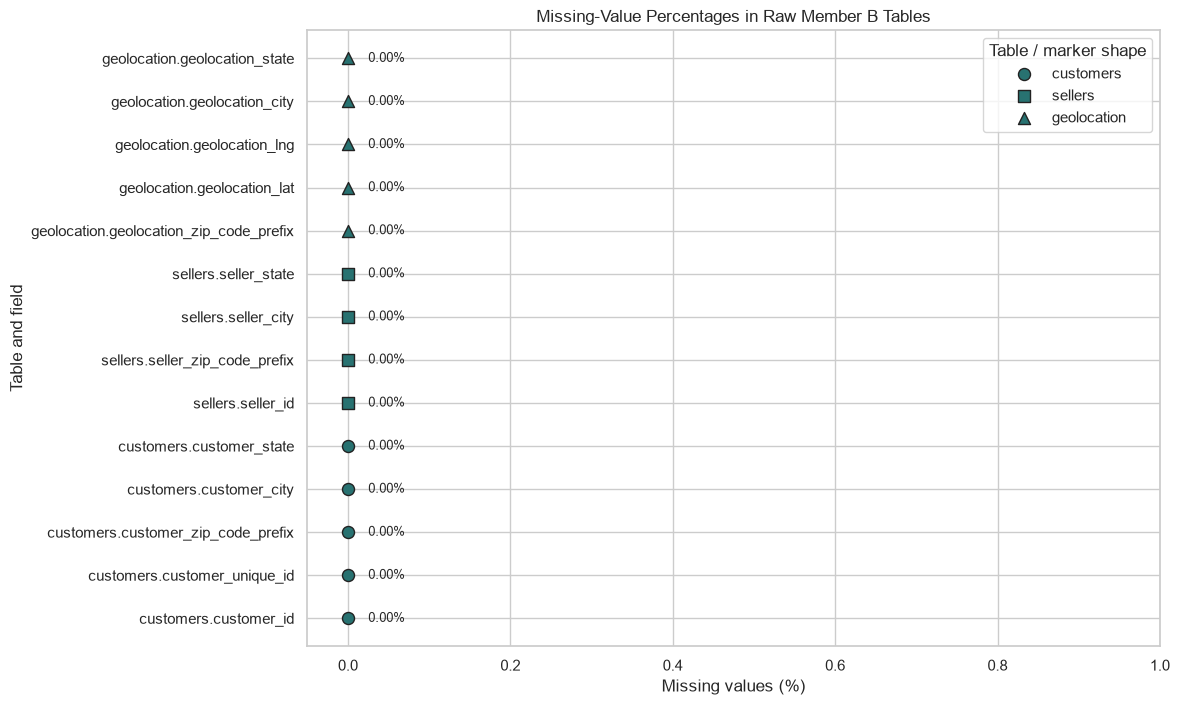

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/missing_value_percentages.png')

In [26]:
missing_plot = missing_summary.reset_index().copy()
missing_plot["field"] = missing_plot["table"] + "." + missing_plot["column"]
marker_by_table = {"customers": "o", "sellers": "s", "geolocation": "^"}

fig, ax = plt.subplots(figsize=(11, 8))
for table_name, table_data in missing_plot.groupby("table", sort=False):
    positions = table_data.index.to_numpy()
    ax.scatter(
        table_data["missing_percentage"],
        positions,
        marker=marker_by_table[table_name],
        s=75,
        color=PRIMARY_COLOR,
        edgecolor=EDGE_COLOR,
        label=table_name,
        zorder=3,
    )
    for percentage, position in zip(table_data["missing_percentage"], positions):
        ax.text(percentage + 0.025, position, f"{percentage:.2f}%", va="center", fontsize=9)
ax.set_yticks(missing_plot.index, missing_plot["field"])
ax.set_xlim(-0.05, 1.0)
ax.set_title("Missing-Value Percentages in Raw Member B Tables")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Table and field")
ax.legend(title="Table / marker shape")
save_figure(fig, "missing_value_percentages.png")

**Observation.** Every audited source column has **0.00% missing values**. This source-level completeness is separate from ZIP enrichment coverage, where unmatched prefixes can still produce missing coordinates.

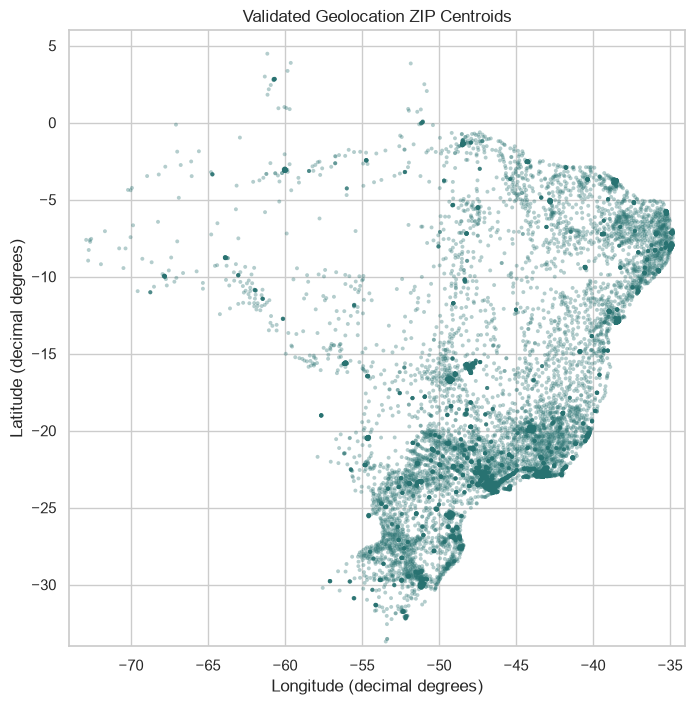

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/geolocation_latitude_longitude_scatter.png')

In [27]:
valid_zip_centroids = geolocation_zip_clean.dropna(subset=["geolocation_lat", "geolocation_lng"])
fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    valid_zip_centroids["geolocation_lng"],
    valid_zip_centroids["geolocation_lat"],
    s=8,
    alpha=0.35,
    color=PRIMARY_COLOR,
    edgecolors="none",
    marker="o",
)
ax.set_xlim(LONGITUDE_MIN, LONGITUDE_MAX)
ax.set_ylim(LATITUDE_MIN, LATITUDE_MAX)
ax.set_title("Validated Geolocation ZIP Centroids")
ax.set_xlabel("Longitude (decimal degrees)")
ax.set_ylabel("Latitude (decimal degrees)")
ax.set_aspect("equal", adjustable="box")
save_figure(fig, "geolocation_latitude_longitude_scatter.png")

**Observation.** The scatter displays **19,010 ZIP centroids with valid coordinates** inside the selected Brazilian bounds. Dense clusters indicate where the source contains more ZIP-prefix centroids; the plot does not measure orders, customers, sellers, or delivery outcomes.

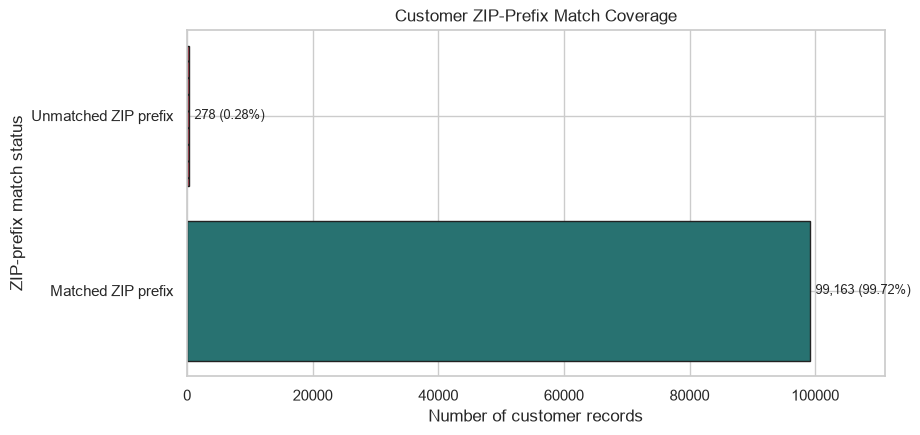

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/customer_zip_match_coverage.png')

In [28]:
customer_zip_matched = customers_geo_clean["customer_geolocation_record_count"].notna()
customer_coverage_counts = pd.Series(
    {"Matched ZIP prefix": int(customer_zip_matched.sum()), "Unmatched ZIP prefix": int((~customer_zip_matched).sum())}
)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    customer_coverage_counts.index,
    customer_coverage_counts.values,
    color=[PRIMARY_COLOR, SECONDARY_COLOR],
    edgecolor=EDGE_COLOR,
    hatch=["", "//"],
)
total_customers = customer_coverage_counts.sum()
label_horizontal_bars(ax, bars, lambda value: f"{int(value):,} ({value / total_customers:.2%})")
ax.set_title("Customer ZIP-Prefix Match Coverage")
ax.set_xlabel("Number of customer records")
ax.set_ylabel("ZIP-prefix match status")
save_figure(fig, "customer_zip_match_coverage.png")

**Observation.** **99,163 of 99,441 customer rows (99.72%)** find a ZIP prefix in the geolocation lookup; 278 do not. One additional matched ZIP has no valid centroid, which is why the broader missing-geolocation indicator covers 279 customer rows.

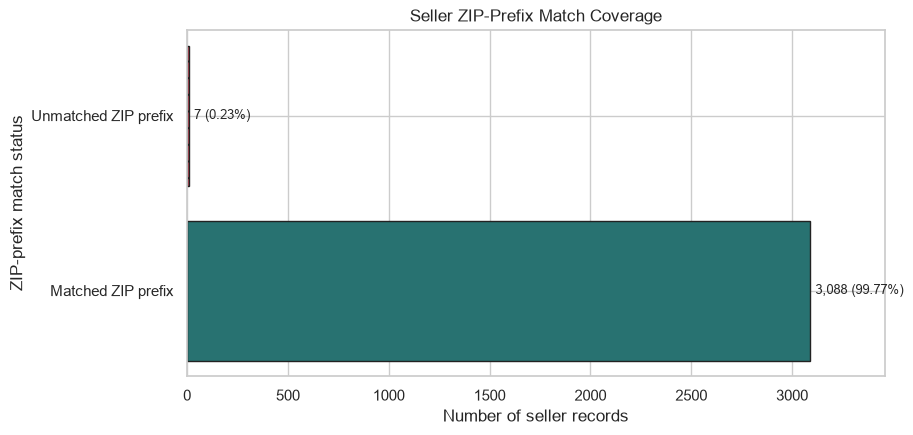

WindowsPath('C:/Users/Hasini/OneDrive/Desktop/FDM project/Olist-late-delivery-prediction/report/figures/member_b/seller_zip_match_coverage.png')

In [29]:
seller_zip_matched = sellers_geo_clean["seller_geolocation_record_count"].notna()
seller_coverage_counts = pd.Series(
    {"Matched ZIP prefix": int(seller_zip_matched.sum()), "Unmatched ZIP prefix": int((~seller_zip_matched).sum())}
)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    seller_coverage_counts.index,
    seller_coverage_counts.values,
    color=[PRIMARY_COLOR, SECONDARY_COLOR],
    edgecolor=EDGE_COLOR,
    hatch=["", "//"],
)
total_sellers = seller_coverage_counts.sum()
label_horizontal_bars(ax, bars, lambda value: f"{int(value):,} ({value / total_sellers:.2%})")
ax.set_title("Seller ZIP-Prefix Match Coverage")
ax.set_xlabel("Number of seller records")
ax.set_ylabel("ZIP-prefix match status")
save_figure(fig, "seller_zip_match_coverage.png")

**Observation.** **3,088 of 3,095 seller rows (99.77%)** find a ZIP prefix in the geolocation lookup, leaving 7 unmatched seller rows. This is descriptive coverage information only.

## 17. Order-Level Geographic Feature Engineering

The orders table will bridge orders to customers, and order_items will bridge orders to sellers. These source files remain read-only and will not be preprocessed here. Planned order-level features may include customer-seller state or region agreement, seller counts, cross-state or cross-region indicators, coordinate availability, and justified distance summaries.

Aggregation must preserve one row per `order_id` and avoid duplicating order-item or product transformations owned by Member C. The resulting feature table will be handed to Member D for the final overall merge.

## 18. Target-Related EDA - Pending Member A's Target

Target-based comparisons are intentionally deferred until Member A supplies the approved target and its definition. Once available, this section may compare geographic feature distributions by target class without recreating, altering, or inferring the target independently.

## 19. Leakage Analysis

Every proposed feature will be reviewed against the model's prediction timestamp. Post-outcome information, including actual delivery outcomes or transformations derived from the target, must not enter Member B outputs.

Encoding, imputation, and scaling for modelling must be fitted after the chronological split and only on the training partition. This notebook may preserve missingness and raw categorical values for downstream fitting rather than learn full-dataset modelling parameters.

## 20. Output Validation

Each processed output will be checked for expected grain, key uniqueness, row counts, schema, missingness, coordinate validity, join coverage, duplicate columns, and reproducibility. Order-level output must contain exactly one row per order represented within Member B's agreed bridge scope.

## 21. Findings and Preprocessing Decisions

Key findings and final decisions will be summarized with supporting evidence and downstream implications. Material conclusions will also be recorded in `report/member_b_findings_and_decisions.md` when implementation is authorized.

## 22. Saving Processed Outputs

After validation, this notebook is expected to create only the following Member B outputs:

- `data/processed/geolocation_zip_clean.csv`
- `data/processed/customers_geo_clean.csv`
- `data/processed/sellers_geo_clean.csv`
- `data/processed/order_geo_features.csv`

Saving will be explicit and will never overwrite raw CSV files. No output is produced by the current notebook scaffold.

## 23. Member B Viva Summary

This section will provide a concise explanation of the source-table grains, main geographic quality issues, preprocessing rationale, engineered features, ownership boundaries, leakage controls, validation results, and limitations. It will be completed after the analysis and preprocessing have been implemented.